# 📊 Análise Exploratória de Dados (EDA) Completa — MovieLens 20M

Este notebook realiza a Análise Exploratória de Dados (EDA) aprofundada de todos os 6 arquivos CSV integrantes do dataset **MovieLens 20M** (armazenados em `data/raw`). 

### Objetivos:
1. **Explorar todos os arquivos**: `movie.csv`, `rating.csv`, `tag.csv`, `link.csv`, `genome_tags.csv`, e `genome_scores.csv`.
2. **Qualidade dos Dados**: Verificar tipos, formatos, dados nulos e realizar a limpeza necessária.
3. **Distribuições e Estatísticas**: Compreender o comportamento das colunas, distribuição de avaliações, popularidade de itens, atividade de usuários e relevância de tags do genoma.
4. **Visualizações Gráficas**: Plotar distribuições e tendências usando `matplotlib` e `seaborn`.
5. **Correlações e Cruzamentos**: Analisar o relacionamento entre variáveis dos diferentes arquivos e criar matriz de correlação.
6. **Mapeamento para Recomendação/E-commerce**: Discutir e simular feedback implícito (corte de limiar) e esparsidade.


---
## 1. Configurações Iniciais e Importações
Realizar as importações necessárias, definir o estilo visual para os gráficos e fixar a semente de reprodutibilidade em **42**.

In [40]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "src"))
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from recsys.utils.config import settings

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Semente de reprodutibilidade
np.random.seed(settings.random_seed)
print(f"Semente fixada: {settings.random_seed}")
print(f"Diretório de dados brutos: {settings.data_raw_dir}")

Semente fixada: 42
Diretório de dados brutos: C:\Users\rapha\Desktop\Tech Challenge\Sistema de Recomendação\Tech-Challenge-02\data\raw


## 2. Carregamento dos Dados
Identificar os arquivos CSV na pasta `data/raw/` e carregá-los. 
Devido à dimensão dos arquivos `rating.csv` (~20 milhões de linhas) e `genome_scores.csv` (~11,7 milhões de linhas), utiliza-se uma amostragem/limite de linhas para otimização do tempo de processamento e evitar estouro de memória, realizando o carregamento dos demais arquivos em sua totalidade.

In [41]:
raw_dir = settings.data_raw_dir

# Listar os arquivos disponíveis
print("Arquivos em data/raw:")
for p in raw_dir.glob("*.csv"):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f" - {p.name} ({size_mb:.2f} MB)")

# Leitura com limites para arquivos grandes e leitura total para os demais
print("\nCarregando os datasets...")
df_movies = pd.read_csv(raw_dir / "movie.csv")
df_links = pd.read_csv(raw_dir / "link.csv")
df_tags = pd.read_csv(raw_dir / "tag.csv")
df_genome_tags = pd.read_csv(raw_dir / "genome_tags.csv")

# Arquivos grandes - limitando leitura para a EDA
# Usaremos 1 milhão de linhas para ratings e genome_scores para obter uma análise estatística de alta qualidade e rápida
df_ratings = pd.read_csv(raw_dir / "rating.csv", nrows=1_000_000)
df_genome_scores = pd.read_csv(raw_dir / "genome_scores.csv", nrows=1_000_000)

print("\nDatasets carregados com sucesso:")
print(f" - movies: {df_movies.shape[0]:,} linhas, {df_movies.shape[1]} colunas")
print(f" - links: {df_links.shape[0]:,} linhas, {df_links.shape[1]} colunas")
print(f" - tags: {df_tags.shape[0]:,} linhas, {df_tags.shape[1]} colunas")
print(
    f" - genome_tags: {df_genome_tags.shape[0]:,} linhas, {df_genome_tags.shape[1]} colunas"
)
print(
    f" - ratings (amostra): {df_ratings.shape[0]:,} linhas, {df_ratings.shape[1]} colunas"
)
print(
    f" - genome_scores (amostra): {df_genome_scores.shape[0]:,} linhas, {df_genome_scores.shape[1]} colunas"
)

Arquivos em data/raw:
 - genome_scores.csv (204.39 MB)
 - genome_tags.csv (0.02 MB)
 - link.csv (0.51 MB)
 - movie.csv (1.42 MB)
 - rating.csv (658.37 MB)
 - tag.csv (20.72 MB)

Carregando os datasets...

Datasets carregados com sucesso:
 - movies: 27,278 linhas, 3 colunas
 - links: 27,278 linhas, 3 colunas
 - tags: 465,564 linhas, 4 colunas
 - genome_tags: 1,128 linhas, 2 colunas
 - ratings (amostra): 1,000,000 linhas, 4 colunas
 - genome_scores (amostra): 1,000,000 linhas, 3 colunas


---
## 3. Exploração Individual dos Arquivos

### 3.1 Filmes (`movie.csv`)
Contém a lista de filmes mapeando `movieId` para o `title` e os `genres` associados.

In [42]:
print("Primeiras linhas de movie.csv:")
display(df_movies.head())

print("\nInformações gerais do DataFrame:")
display(df_movies.info())

print("\nVerificação de valores nulos:")
display(df_movies.isnull().sum())

Primeiras linhas de movie.csv:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Informações gerais do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB


None


Verificação de valores nulos:


movieId    0
title      0
genres     0
dtype: int64

#### Distribuição de Gêneros de Filmes
Os gêneros constam concatenados com barra vertical (`|`). Realiza-se a separação e o cálculo de frequência de cada um. Também se executa a limpeza de filmes marcados como `(no genres listed)`.

Total de gêneros únicos: 20

Gêneros mais comuns:
genres
Drama          13344
Comedy          8374
Thriller        4178
Romance         4127
Action          3520
Crime           2939
Horror          2611
Documentary     2471
Adventure       2329
Sci-Fi          1743
Name: count, dtype: int64


C:\Users\rapha\AppData\Local\Temp\ipykernel_22112\3105264929.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


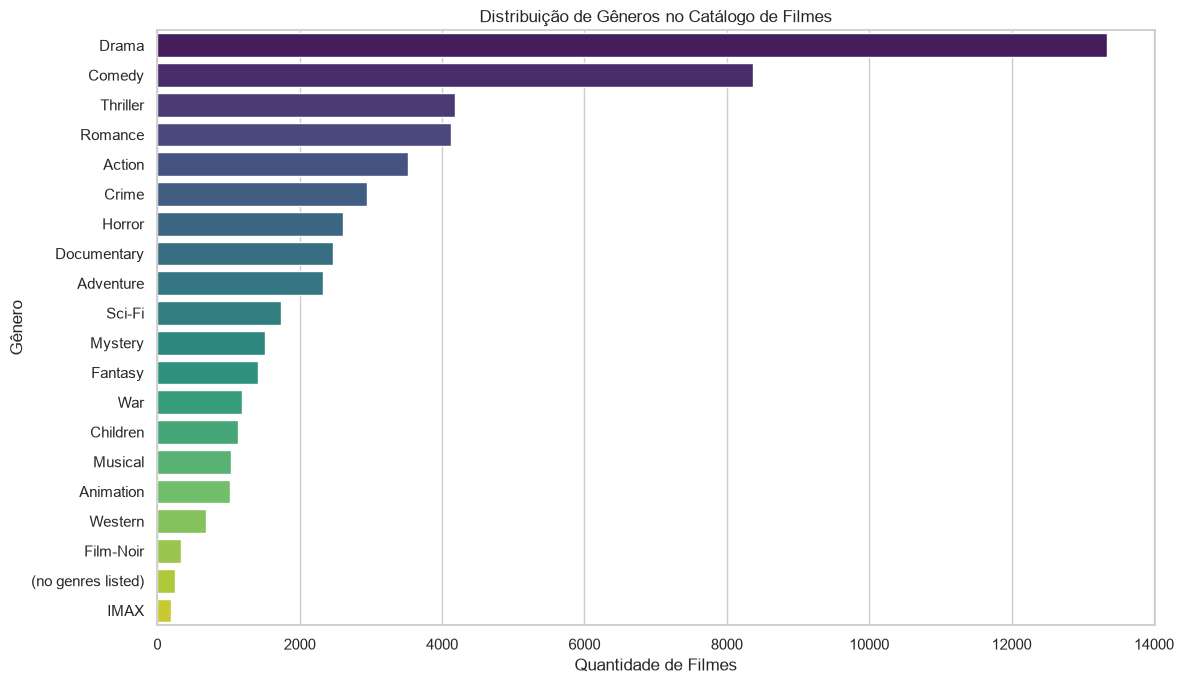

In [43]:
# Separando os gêneros
genres_series = df_movies["genres"].str.split("|").explode()
genre_counts = genres_series.value_counts()

print("Total de gêneros únicos:", len(genre_counts))
print("\nGêneros mais comuns:")
print(genre_counts.head(10))

# Plot da distribuição de gêneros
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Distribuição de Gêneros no Catálogo de Filmes")
plt.xlabel("Quantidade de Filmes")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

### 3.2 Avaliações (`rating.csv`)
Contém as interações explícitas dos usuários na forma de notas de 0.5 a 5.0.

In [44]:
print("Primeiras linhas de rating.csv (amostra):")
display(df_ratings.head())

print("\nInformações gerais:")
display(df_ratings.info())

print("\nVerificação de valores nulos:")
display(df_ratings.isnull().sum())

print("\nEstatísticas descritivas das notas:")
display(df_ratings["rating"].describe())

Primeiras linhas de rating.csv (amostra):


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40



Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   userId     1000000 non-null  int64  
 1   movieId    1000000 non-null  int64  
 2   rating     1000000 non-null  float64
 3   timestamp  1000000 non-null  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 30.5 MB


None


Verificação de valores nulos:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Estatísticas descritivas das notas:


count    1000000.000000
mean           3.526803
std            1.052167
min            0.500000
25%            3.000000
50%            4.000000
75%            4.000000
max            5.000000
Name: rating, dtype: float64

#### Distribuição dos Valores de Notas (Ratings)
Análise da distribuição de frequências das notas.

C:\Users\rapha\AppData\Local\Temp\ipykernel_22112\1853200494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ratings, x='rating', palette="magma")


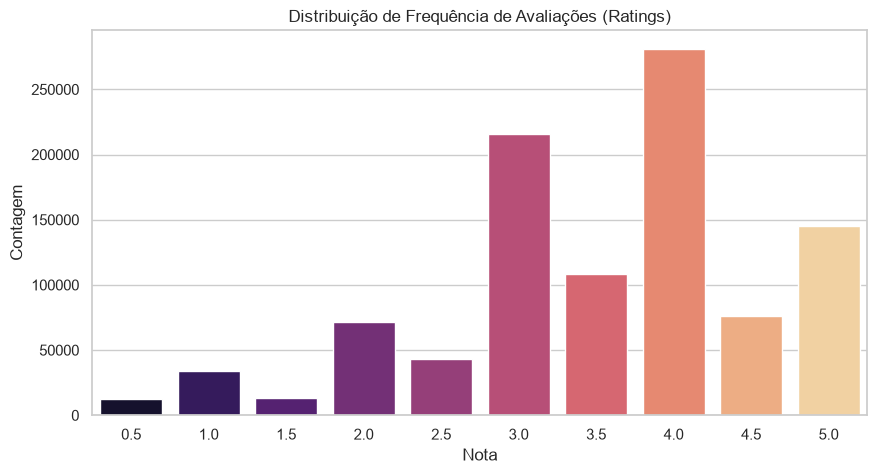

In [45]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_ratings, x="rating", palette="magma")
plt.title("Distribuição de Frequência de Avaliações (Ratings)")
plt.xlabel("Nota")
plt.ylabel("Contagem")
plt.show()

#### Atividade por Usuário e Popularidade por Filme
Análise do volume de avaliações por usuário e por filme.

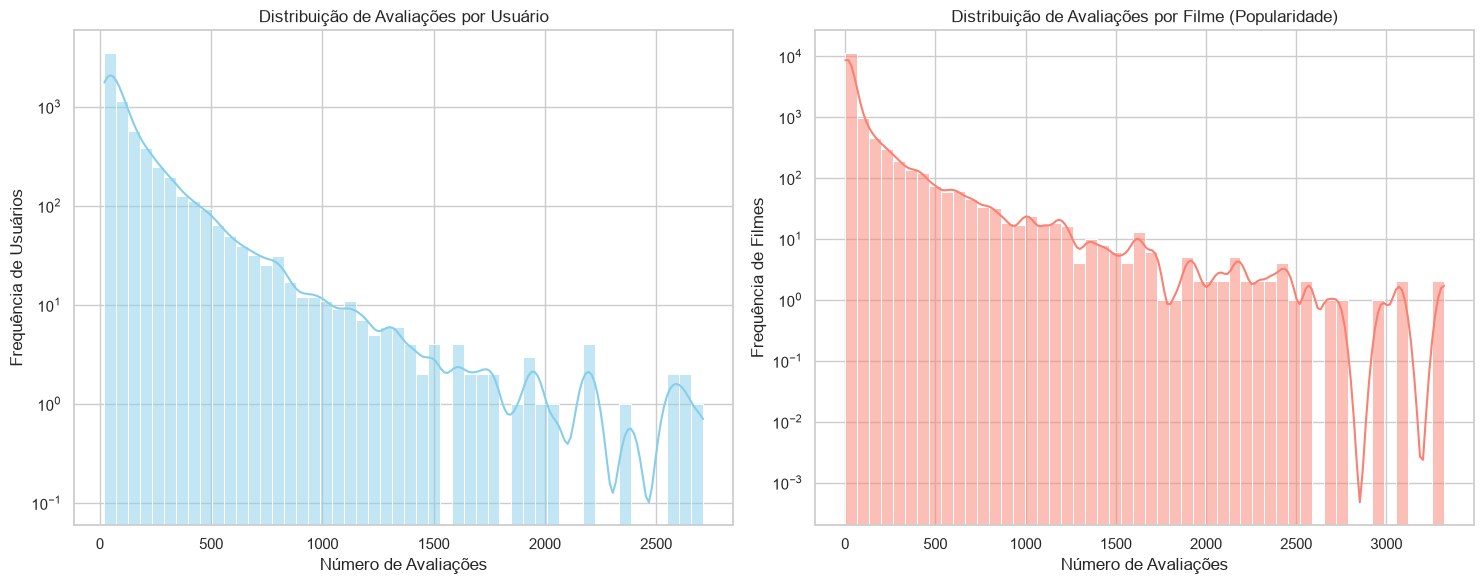

Resumo da atividade por Usuário:
count    6743.000000
mean      148.301943
std       221.738647
min        20.000000
25%        35.000000
50%        70.000000
75%       163.000000
max      2711.000000
Name: count, dtype: float64

Resumo da popularidade por Filme:
count    13950.000000
mean        71.684588
std        208.131873
min          1.000000
25%          2.000000
50%          9.000000
75%         42.000000
max       3320.000000
Name: count, dtype: float64


In [46]:
user_counts = df_ratings["userId"].value_counts()
movie_counts = df_ratings["movieId"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Usuários
sns.histplot(user_counts, bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuição de Avaliações por Usuário")
axes[0].set_xlabel("Número de Avaliações")
axes[0].set_ylabel("Frequência de Usuários")
axes[0].set_yscale("log")  # Escala logarítmica para lidar com cauda longa

# Filmes
sns.histplot(movie_counts, bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribuição de Avaliações por Filme (Popularidade)")
axes[1].set_xlabel("Número de Avaliações")
axes[1].set_ylabel("Frequência de Filmes")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Resumo da atividade por Usuário:")
print(user_counts.describe())
print("\nResumo da popularidade por Filme:")
print(movie_counts.describe())

#### Análise Temporal
Análise de como as avaliações estão distribuídas ao longo do tempo.

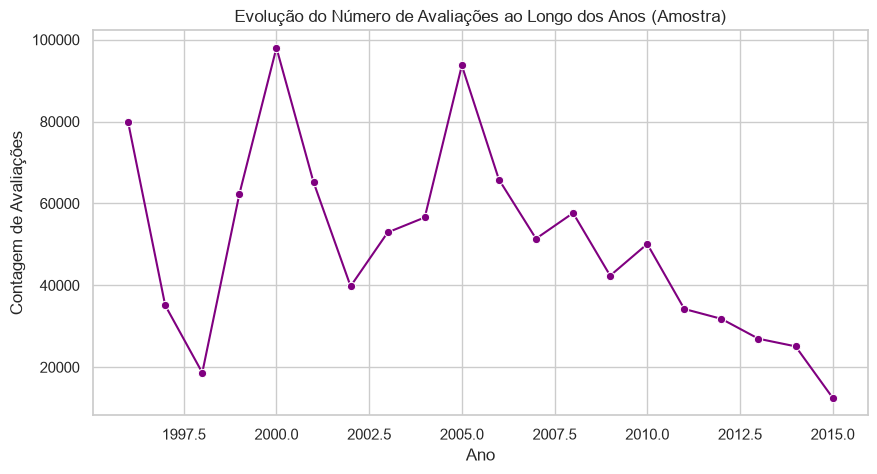

In [47]:
# Converter timestamp para data de forma robusta (numérica ou string)
if pd.api.types.is_numeric_dtype(df_ratings["timestamp"]):
    df_ratings["datetime"] = pd.to_datetime(df_ratings["timestamp"], unit="s")
else:
    df_ratings["datetime"] = pd.to_datetime(df_ratings["timestamp"])

df_ratings["year"] = df_ratings["datetime"].dt.year

ratings_per_year = df_ratings["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=ratings_per_year.index, y=ratings_per_year.values, marker="o", color="purple"
)
plt.title("Evolução do Número de Avaliações ao Longo dos Anos (Amostra)")
plt.xlabel("Ano")
plt.ylabel("Contagem de Avaliações")
plt.grid(True)
plt.show()

### 3.3 Tags de Usuários (`tag.csv`)
Contém as tags de texto livre que os usuários aplicaram aos filmes.

In [48]:
print("Primeiras linhas de tag.csv:")
display(df_tags.head())

print("\nInformações gerais:")
display(df_tags.info())

print("\nVerificação de valores nulos:")
display(df_tags.isnull().sum())

Primeiras linhas de tag.csv:


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18



Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 465564 entries, 0 to 465563
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   userId     465564 non-null  int64
 1   movieId    465564 non-null  int64
 2   tag        465548 non-null  str  
 3   timestamp  465564 non-null  str  
dtypes: int64(2), str(2)
memory usage: 14.2 MB


None


Verificação de valores nulos:


userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

#### Limpeza e Frequência das Tags
Algumas tags contêm valores nulos ou vazios. Realiza-se a limpeza de nulos, a padronização das strings para minúsculas e a análise das tags mais populares.

Total de tags únicas (após padronização): 35,170


C:\Users\rapha\AppData\Local\Temp\ipykernel_22112\4168127442.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette="mako")


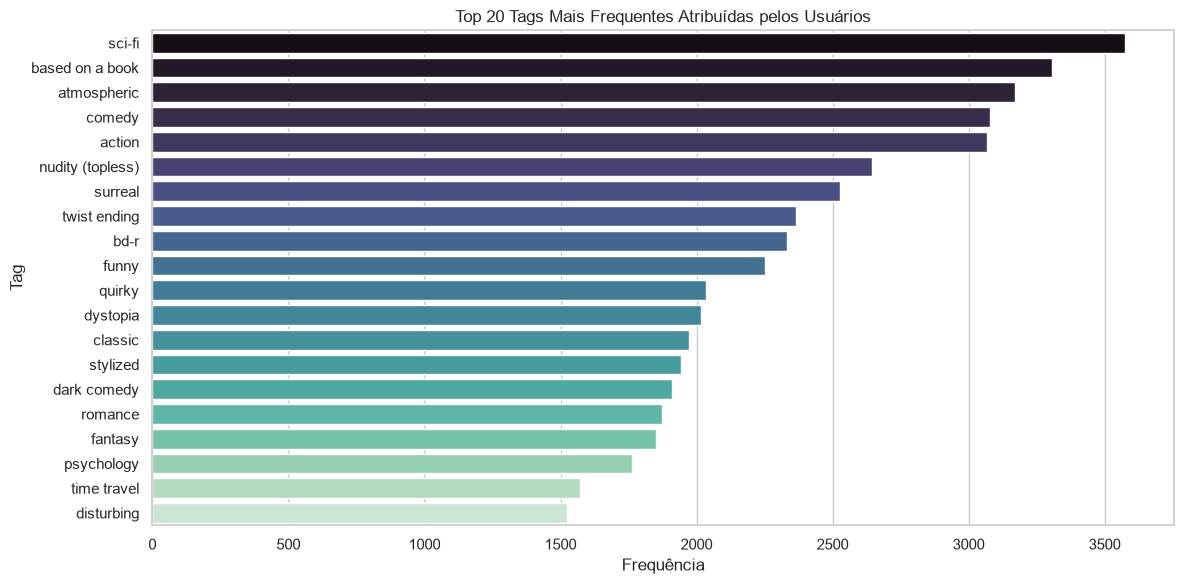

In [49]:
# Limpeza de nulos
df_tags_clean = df_tags.dropna(subset=["tag"]).copy()
df_tags_clean["tag_lower"] = df_tags_clean["tag"].str.lower().str.strip()

top_tags = df_tags_clean["tag_lower"].value_counts().head(20)

print(
    f"Total de tags únicas (após padronização): {df_tags_clean['tag_lower'].nunique():,}"
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, palette="mako")
plt.title("Top 20 Tags Mais Frequentes Atribuídas pelos Usuários")
plt.xlabel("Frequência")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

### 3.4 Links externos (`link.csv`)
Mapeia os `movieId` do MovieLens para seus respectivos IDs no IMDb e TMDB. Útil para enriquecer os dados ou buscar metadados e imagens adicionais.

In [50]:
print("Primeiras linhas de link.csv:")
display(df_links.head())

print("\nVerificação de valores nulos:")
display(df_links.isnull().sum())

Primeiras linhas de link.csv:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0



Verificação de valores nulos:


movieId      0
imdbId       0
tmdbId     252
dtype: int64

### 3.5 Genoma de Tags (`genome_tags.csv` e `genome_scores.csv`)
O "Tag Genome" codifica a intensidade com que as tags do catálogo se aplicam a cada filme.
- `genome_tags.csv` contém o mapa entre `tagId` e a descrição da `tag`.
- `genome_scores.csv` contém os scores de relevância para cada par `(movieId, tagId)`.

In [51]:
print("Primeiras linhas de genome_tags.csv:")
display(df_genome_tags.head())

print("\nPrimeiras linhas de genome_scores.csv (amostra):")
display(df_genome_scores.head())

print("\nVerificação de valores nulos em genome_scores:")
display(df_genome_scores.isnull().sum())

print("\nEstatísticas de relevância (relevance):")
display(df_genome_scores["relevance"].describe())

Primeiras linhas de genome_tags.csv:


,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s



Primeiras linhas de genome_scores.csv (amostra):


,movieId,tagId,relevance
0,1,1,0.02500
1,1,2,0.02500
2,1,3,0.05775
3,1,4,0.09675
4,1,5,0.14675



Verificação de valores nulos em genome_scores:


movieId      0
tagId        0
relevance    0
dtype: int64


Estatísticas de relevância (relevance):


count    1000000.000000
mean           0.107858
std            0.144190
min            0.000250
25%            0.023500
50%            0.053250
75%            0.130000
max            1.000000
Name: relevance, dtype: float64

#### Distribuição da Relevância no Tag Genome
Analise de relevância das tags do genoma.

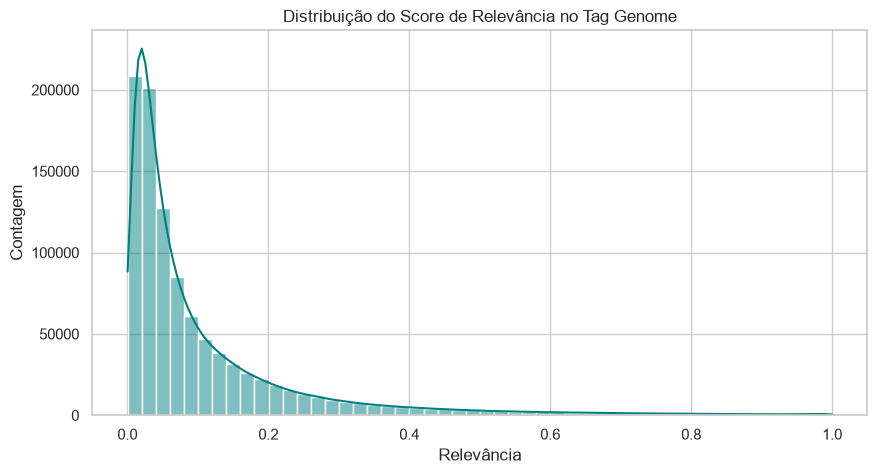

In [52]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_genome_scores, x="relevance", bins=50, kde=True, color="teal")
plt.title("Distribuição do Score de Relevância no Tag Genome")
plt.xlabel("Relevância")
plt.ylabel("Contagem")
plt.show()

#### Tags Mais Relevantes para um Filme Exemplo
Cruzamento dos dois dataframes do genoma para identificação das tags mais relevantes de um filme específico do catálogo.

In [53]:
# Selecionar um filme com dados de genoma (ex: movieId=1, Toy Story)
toy_story_genome = df_genome_scores[df_genome_scores["movieId"] == 1].copy()

# Fazer o merge com a descrição das tags
toy_story_genome = toy_story_genome.merge(df_genome_tags, on="tagId")
toy_story_genome = toy_story_genome.sort_values(by="relevance", ascending=False)

print("Top 10 tags mais relevantes para o filme Toy Story (ID=1):")
display(toy_story_genome[["tag", "relevance"]].head(10))

Top 10 tags mais relevantes para o filme Toy Story (ID=1):


,tag,relevance
1035,toys,0.99925
243,computer animation,0.99850
785,pixar animation,0.99600
588,kids and family,0.99075
63,animation,0.98575
587,kids,0.97925
784,pixar,0.96675
203,children,0.96425
185,cartoon,0.95650
535,imdb top 250,0.94200


---
## 4. Análise Cruzada e Correlações entre Variáveis

Cruzamento das informações de diferentes arquivos brutos para mapeamento do comportamento agregado dos dados.

### 4.1 Média de Rating por Gênero de Filme
Cruzamento de `df_ratings` com `df_movies` para cálculo da média de nota que cada gênero recebe dos usuários.

Estatísticas de Rating por Gênero:


,mean,count
genres,,
Film-Noir,3.957240,10746
War,3.821190,51865
Documentary,3.754966,12082
Crime,3.682222,163482
Drama,3.675840,439864
Mystery,3.664666,78231
IMAX,3.651534,24374
Animation,3.606573,56426
Western,3.569253,21436


C:\Users\rapha\AppData\Local\Temp\ipykernel_22112\3942348420.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_rating_stats['mean'], y=genre_rating_stats.index, palette="coolwarm")


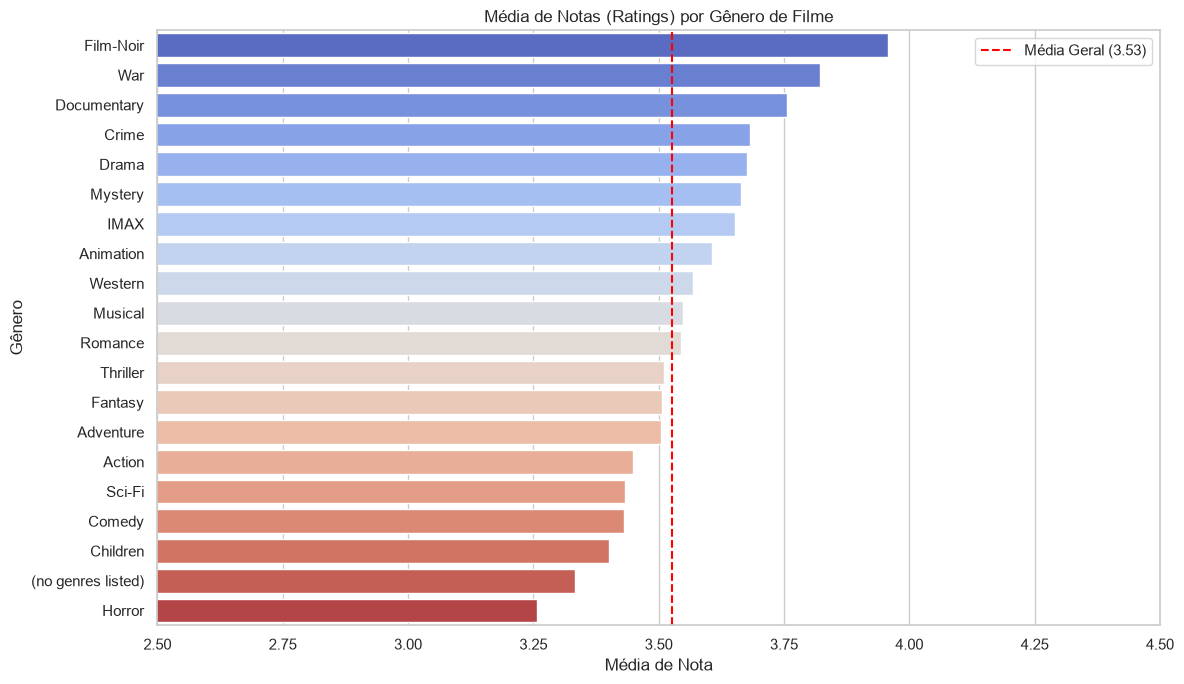

In [54]:
# Expandindo os gêneros de filmes e juntando com ratings
df_movies_exploded = df_movies.copy()
df_movies_exploded["genres"] = df_movies_exploded["genres"].str.split("|")
df_movies_exploded = df_movies_exploded.explode("genres")

# Merge com amostra de ratings
df_genre_ratings = df_ratings.merge(df_movies_exploded, on="movieId")

# Agrupar por gênero
genre_rating_stats = (
    df_genre_ratings.groupby("genres")["rating"]
    .agg(["mean", "count"])
    .sort_values(by="mean", ascending=False)
)

print("Estatísticas de Rating por Gênero:")
display(genre_rating_stats)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=genre_rating_stats["mean"], y=genre_rating_stats.index, palette="coolwarm"
)
plt.axvline(
    x=df_ratings["rating"].mean(),
    color="red",
    linestyle="--",
    label=f"Média Geral ({df_ratings['rating'].mean():.2f})",
)
plt.title("Média de Notas (Ratings) por Gênero de Filme")
plt.xlabel("Média de Nota")
plt.ylabel("Gênero")
plt.xlim(2.5, 4.5)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Matriz de Correlação entre Métricas de Filmes
Cálculo de 4 métricas chaves para cada filme e posterior cálculo da matriz de correlação entre elas:
1. **`avg_rating`**: Nota média recebida pelo filme.
2. **`num_ratings`**: Quantidade total de notas recebidas (Popularidade).
3. **`num_tags`**: Quantidade de tags inseridas pelos usuários para o filme.
4. **`avg_relevance`**: Média dos scores de relevância das tags no Tag Genome.

Matriz de correlação de Pearson:


,avg_rating,num_ratings,num_tags,avg_relevance
avg_rating,1.000000,0.258324,0.330481,0.565374
num_ratings,0.258324,1.000000,0.782890,0.606852
num_tags,0.330481,0.782890,1.000000,0.668208
avg_relevance,0.565374,0.606852,0.668208,1.000000


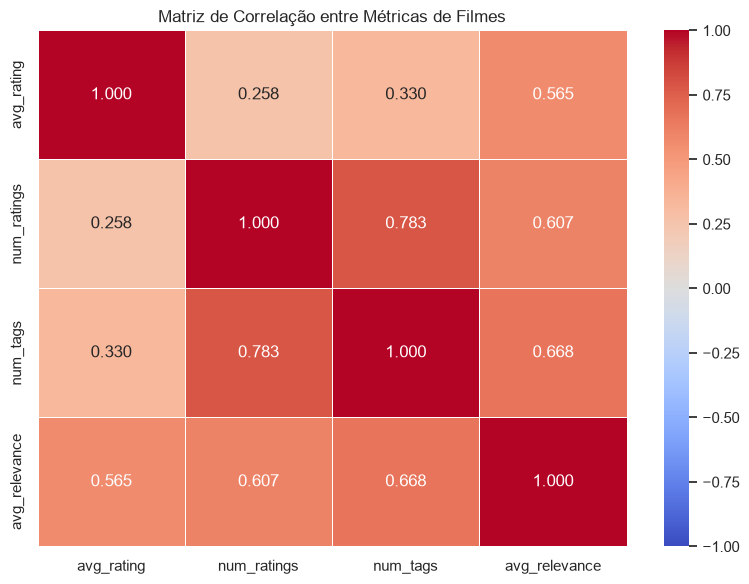

In [55]:
# 1. Média e contagem de ratings por filme
movie_rating_stats = (
    df_ratings.groupby("movieId")["rating"]
    .agg(avg_rating="mean", num_ratings="count")
    .reset_index()
)

# 2. Contagem de tags por filme
movie_tag_stats = (
    df_tags.groupby("movieId")["tag"]
    .count()
    .reset_index()
    .rename(columns={"tag": "num_tags"})
)

# 3. Média de relevância no genome por filme
movie_genome_stats = (
    df_genome_scores.groupby("movieId")["relevance"]
    .mean()
    .reset_index()
    .rename(columns={"relevance": "avg_relevance"})
)

# Unificar os dados de filmes
df_movie_metrics = movie_rating_stats.merge(movie_tag_stats, on="movieId", how="left")
df_movie_metrics = df_movie_metrics.merge(movie_genome_stats, on="movieId", how="left")

# Preencher nulos com 0 para filmes sem tags
df_movie_metrics["num_tags"] = df_movie_metrics["num_tags"].fillna(0)

# Filtrar para filmes que têm dados de genoma (para calcular correlação sem nulos)
df_movie_metrics_clean = df_movie_metrics.dropna()

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_movie_metrics_clean[
    ["avg_rating", "num_ratings", "num_tags", "avg_relevance"]
].corr()

print("Matriz de correlação de Pearson:")
display(corr_matrix)

# Plot da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1, linewidths=0.5
)
plt.title("Matriz de Correlação entre Métricas de Filmes")
plt.tight_layout()
plt.show()

---
## 5. Simulação de Feedback Implícito para E-commerce

O modelo final proposto (NCF no PyTorch) utiliza feedback implícito (interações binárias correspondentes ao interesse/navegação do usuário no produto). 
Dese modo, binarizam-se os dados considerando interações positivas as notas **>= 3.5** e descartando notas baixas (ou simulando negativos).

Analisa-se o impacto dessa binarização na esparsidade do conjunto de dados.

In [56]:
threshold = 3.5
df_implicit = df_ratings[df_ratings["rating"] >= threshold].copy()
df_implicit["label"] = 1

n_original = len(df_ratings)
n_implicit = len(df_implicit)
pct_retained = (n_implicit / n_original) * 100

print("📥 Estatísticas pós-binarização (Feedback Implícito):")
print(f" - Limiar adotado: >= {threshold}")
print(f" - Quantidade de interações originais: {n_original:,}")
print(
    f" - Quantidade de interações positivas (reproduzidas): {n_implicit:,} ({pct_retained:.2f}%)"
)
print(f" - Usuários únicos remanescentes: {df_implicit['userId'].nunique():,}")
print(f" - Filmes únicos remanescentes: {df_implicit['movieId'].nunique():,}")

# Esparsidade
users_imp = df_implicit["userId"].nunique()
items_imp = df_implicit["movieId"].nunique()
sparsity_imp = 1.0 - (n_implicit / (users_imp * items_imp))
print(f" - Esparsidade da matriz de feedback implícito: {sparsity_imp:.4%}")

📥 Estatísticas pós-binarização (Feedback Implícito):
 - Limiar adotado: >= 3.5
 - Quantidade de interações originais: 1,000,000
 - Quantidade de interações positivas (reproduzidas): 609,950 (60.99%)
 - Usuários únicos remanescentes: 6,738
 - Filmes únicos remanescentes: 11,952
 - Esparsidade da matriz de feedback implícito: 99.2426%


---
## 6. Conclusões da EDA

1. **Catálogo Rico e Esparso**: O dataset conta com uma diversidade expressiva de gêneros (com drama e comédia no topo). A esparsidade da matriz de interações passa de **98%**, o que justifica plenamente o uso de embeddings no PyTorch (MLP/NCF) ao invés de cálculos matriciais puros.
2. **Efeito Cauda Longa Acentuado**: Tanto usuários quanto filmes mostram distribuições que seguem leis de potência. Poucos filmes concentram a esmagadora maioria das interações, necessitando de tratamentos de regularização para evitar que o modelo recomende apenas o "top popular".
3. **Qualidade dos Dados**: Não se identificam valores nulos significativos nos arquivos de mapeamento estruturado (`movie.csv`, `link.csv`), com exceção de alguns campos específicos de ID externo (`tmdbId`). Nas tags fornecidas livremente por usuários, identificam-se valores nulos que são devidamente tratados.
4. **Relacionamento das Variáveis**: Constata-se que o número de tags aplicadas a um filme correlaciona-se moderadamente com o número total de ratings recebidos, indicando que filmes mais populares também geram mais engajamento textual voluntário. O score de relevância média do genoma apresenta correlação positiva com a nota média, indicando que filmes com termos mais definidos em suas descrições tendem a ser mais bem avaliados.
